In [4]:
!pip install --quiet accelerate
!pip install --quiet bitsandbytes
!pip install --quiet datasets
!pip install --quiet -U ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 27.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 21.1 MB/s eta 0:00:00:00:0100:01


In [5]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [6]:
import transformers
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, GenerationConfig
from huggingface_hub import hf_hub_download, login

import torch
from torch import Tensor, nn

import numpy as np

import math
import json
import random
import zlib
import base64
import ast
import tokenize
import itertools
import io
import re
import gc
import pickle

import pandas as pd

from abc import ABC, abstractmethod
from dataclasses import dataclass, field, asdict
from pydantic import BaseModel
from typing import List, Dict, Any, Optional
from tqdm import tqdm
import json

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
hf_token = ''

In [10]:
login(token=hf_token)

In [11]:
%%writefile eval_dto.py
from pydantic import BaseModel, Field
from typing import List, Dict, Any, Optional
import numpy as np
import scipy.special

class Stats(BaseModel):
    all_stats: List[Dict]  = Field(default_factory=list)
    best_stats: Dict = Field(default_factory=lambda: {'correct': False, 'score': 0.0, 'reward': 0.0, 'completion': ""})
    
    def add(self, stats):
        self.all_stats.append(stats)
        if stats['reward'] > self.best_stats['reward']:
            self.best_stats = stats

    # As ORM is not GT verifier, reward going up does not always translate into higher accuracy
    # Such variant allows to see whether this result in model deceiving the ORM or finiding consistent strategy 
    def pass_k_orm(self, k):
        current_stats = self.all_stats[:k]
        current_best = max(current_stats, key=lambda s: s['reward'])

        return 1.0 if current_best['correct'] else 0.0

    def pass_k_noisy(self, k):
        c = len([s for s in self.all_stats[:k] if s['correct']])

        return 1.0 if c > 0 else 0.0

    def rm_k(self, k):
        rm_scores = np.array([s['reward'] for s in self.all_stats])
        gt_labels = np.array([s['correct'] for s in self.all_stats])
        N = len(rm_scores)

        sort_indices = np.argsort(rm_scores)[::-1]
        sorted_gt = gt_labels[sort_indices]
            
        j = np.arange(N)
        worse_items = N - 1 - j
        results = {}
        
        ways_to_be_best = scipy.special.comb(worse_items, k - 1, exact=False)
        total_combinations = scipy.special.comb(N, k, exact=False)
        expected_pass = np.sum(sorted_gt * ways_to_be_best) / total_combinations if total_combinations > 0 else 0.0

        return expected_pass
        
    def pass_k(self, k):
        n = len(self.all_stats)
        c = len([s for s in self.all_stats if s['correct']])
    
        if n - c < k:
            return 1.0
        
        return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

class TaskState(BaseModel):
    task_id: str
    task_data: Any
    conversation: List[Dict[str, str]] = Field(default_factory=list)
    agent_states: Optional[List[Any]] = None
    attempts: int = 0
    is_done: bool = False
    stats: Stats = Field(default_factory=dict)

class BenchmarkResults(BaseModel):
    items: List[TaskState]
    metadata: Dict[str, Any]

Writing eval_dto.py


In [12]:
from eval_dto import *

In [13]:
os.environ['FLASHINFER_DISABLE_VERSION_CHECK'] = '1'

In [14]:
import ray
ray.init(num_gpus=2, log_to_driver=True, ignore_reinit_error=True)

ImportError: cannot import name 'get_default_ray_temp_dir' from 'ray._common.utils' (/usr/local/lib/python3.12/dist-packages/ray/_common/utils.py)

The following actor was used to evaluate sampled trajectories in batch as they're not dependent on intermediate rewards.

In [15]:
%%writefile ray_worker.py
import torch
from torch import Tensor, nn

import numpy as np

import math

from typing import List, Optional, Tuple, Dict, Any, Union

import copy
import traceback

import transformers
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification, BitsAndBytesConfig, GenerationConfig
from huggingface_hub import hf_hub_download, login

import json
import random
import zlib
import base64
import ast
import tokenize
import itertools
import io
import os
import re
import gc
import pickle
import time

import pandas as pd

from abc import ABC, abstractmethod
from dataclasses import dataclass, field, asdict
from pydantic import BaseModel
from typing import List, Dict, Any, Optional
from tqdm import tqdm
import json

import ray

from pydantic import BaseModel, Field, ConfigDict, field_serializer, field_validator
from eval_dto import *

import warnings
import itertools

@ray.remote(num_gpus=1)
class RewardActor(object):
    def __init__(self):
        model_name = "Skywork/Skywork-Reward-V2-Llama-3.2-3B"
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            dtype=torch.float16,
            device_map="cuda:0",
            num_labels=1,
        )
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def rewarding_job(self, task, batch_size):
        stats = task.stats.all_stats
        new_stats = Stats()

        convos = []
        for stat in stats:
            convo = copy.copy(task.conversation) + [{'role': 'assistant', 'content': stat['completion']}]
            convos.append(convo)
        
        stat_batches = list(itertools.batched(stats, batch_size))
        convo_batches = list(itertools.batched(convos, batch_size))
        for stats, convos in zip(stat_batches, convo_batches):
            scores = self.get_reward(convos)
            for stat, score in zip(stats, scores):
                stat['reward'] = score
                new_stats.add(stat)

        task.stats = new_stats
        return task
    
    def get_reward(self, conversations):
        convs_formatted = self.tokenizer.apply_chat_template(conversations, tokenize=False)
        for i in range(len(conversations)):
            if self.tokenizer.bos_token is not None and convs_formatted[i].startswith(self.tokenizer.bos_token):
                convs_formatted[i] = convs_formatted[i][len(self.tokenizer.bos_token):]
        
        conv_tokenized = self.tokenizer(
            convs_formatted, 
            padding=True,
            truncation=True,
            max_length=1024,
            return_tensors="pt"
        ).to(self.model.device)
        
        with torch.no_grad():
            score = self.model(**conv_tokenized).logits
            normalized_score = torch.sigmoid((score - 10) / 5)
            
        return normalized_score.flatten().tolist()

Overwriting my_ray_worker.py


In [ ]:
from ray_worker import RewardActor

As the tasks were evaluated in chunks, these chunks were merged with the following method

In [16]:
file_paths = [
    f'',
]

def parse_results(file_path_full):
    with open(file_path_full, 'r') as f:
        json_data = json.load(f)
        try:
            results = BenchmarkResults(**json_data)
        except ValidationError as e:
            print(e.errors())

            for error in e.errors():
                print(f"Field: {error['loc']}, Error: {error['msg']}")

            results = None
    
    return results 

def merge_runs(results):
    all_items = list(itertools.chain(*[result.items for result in results]))
    all_items_sorted = sorted(all_items, key=lambda x: x.task_id)
    
    return BenchmarkResults(metadata=results[0].metadata, items=all_items_sorted)

runs = [parse_results(path) for path in file_paths]
results = merge_runs(runs)

0.6621621621621622


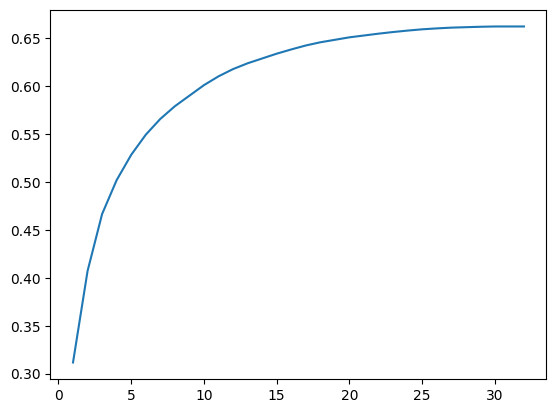

0.6621621621621622


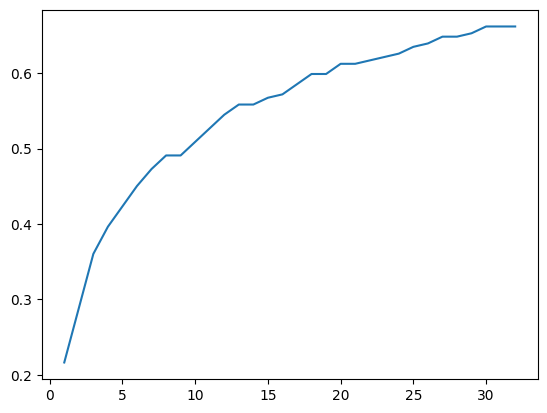

0.6621621621621622


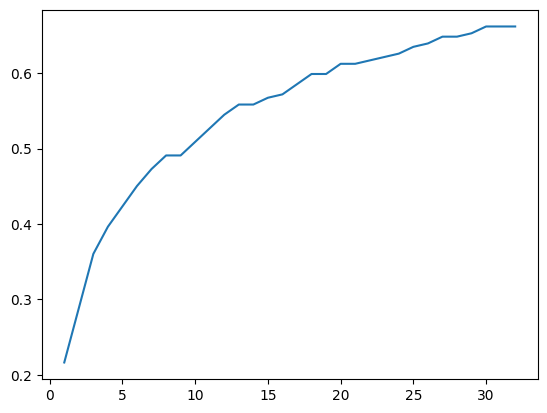

0.0


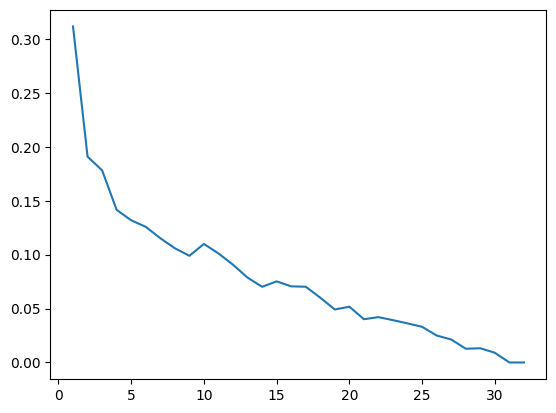

In [17]:
max_attempts =  max([t.attempts for t in results.items])

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:    
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.pass_k(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.pass_k_noisy(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.pass_k_orm(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.rm_k(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

In [ ]:
budget = 2

workers = []
for i in range(budget):
    worker = RewardActor.remote()
    workers.append(worker)

In [ ]:
from ray.util.actor_pool import ActorPool
from ray.util.queue import Queue
import itertools
import traceback
from tqdm import tqdm

pool = ActorPool(workers)
tasks = results.items

map_task = pool.map(lambda a, t: a.rewarding_job.remote(t, 4), tasks)

rerewarded_tasks = []
for _ in tqdm(range(len(tasks))):
    rerewarded_task = pool.get_next()
    rerewarded_tasks.append(rerewarded_task)

results.items = rerewarded_tasks

In [ ]:
max_attempts = max([t.attempts for t in results.items])

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:    
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.pass_k(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.pass_k_noisy(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.pass_k_orm(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

xs = list(range(1, max_attempts+1))
ys = []

for k in xs:
    pass_k_total = 0.0
    for t in results.items:
        pass_k_total += t.stats.rm_k(k)

    pass_k = pass_k_total / len(results.items)
    ys.append(pass_k)

    if k == xs[-1]:
        print(pass_k)

sns.lineplot(x=xs, y=ys)
plt.show()

In [16]:
results_dict = results.model_dump()
new_file_path = 'Llama-3.2-3B-Instruct (lcb_sampling_gt).json'

with open(new_file_path, 'w') as f:
    json.dump(results_dict, f, indent=4)